In [2]:
!pip install -q pennylane pennylane-lightning[gpu]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.6/924.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 11.2 MB/s eta 0:00:00


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# ==========================================================
# GPU CHECK
# ==========================================================

print("="*60)
print("GPU STATUS")
print("="*60)

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

try:
    dev_test = qml.device("lightning.gpu", wires=2)
    print("Lightning GPU Connected")
except:
    print("Lightning GPU NOT Connected")

print("="*60)


GPU STATUS
CUDA Available : True
GPU : Tesla T4
Lightning GPU Connected


In [5]:
# ==========================================================
# SEGMENT 1 : LOAD DATASET
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/Student Depression Dataset.csv")
df = df.dropna()

# Remove ID Columns
for col in ["Student_ID", "student_id", "ID", "id"]:
    if col in df.columns:
        df = df.drop(columns=[col])

print(df.shape)
df.head()

(27898, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [65]:
print(df["Sleep Duration"].unique())
print(df["Dietary Habits"].unique())
print(df["Have you ever had suicidal thoughts ?"].unique())

[0 2 1 3 4]
[0 1 3 2]
[1 0]


In [6]:
# ==========================================================
# SEGMENT 2 : LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()

for col in df.columns:
    if col != "Depression":
        if df[col].dtype == "object":
            df[col] = encoder.fit_transform(df[col])

y = encoder.fit_transform(df["Depression"])

X = df.drop(columns=["Depression"])

feature_names = X.columns.tolist()

print("=" * 60)
print("Total Features :", len(feature_names))
print("=" * 60)

Total Features : 16


In [7]:
df

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,51,11,5.0,0.0,8.97,2.0,0.0,0,0,3,1,3.0,1.0,0,1
1,0,24.0,3,11,2.0,0.0,5.90,5.0,0.0,0,1,10,0,3.0,2.0,1,0
2,1,31.0,44,11,3.0,0.0,7.03,5.0,0.0,2,0,5,0,9.0,1.0,1,0
3,0,28.0,49,11,3.0,0.0,5.59,2.0,0.0,1,1,7,1,4.0,5.0,1,1
4,0,25.0,16,11,4.0,0.0,8.13,3.0,0.0,0,1,17,1,1.0,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0,27.0,45,11,5.0,0.0,5.75,5.0,0.0,0,3,11,1,7.0,1.0,1,0
27897,1,27.0,25,11,2.0,0.0,9.40,3.0,0.0,2,0,25,0,0.0,3.0,1,0
27898,1,31.0,9,11,3.0,0.0,6.61,4.0,0.0,0,3,22,0,12.0,2.0,0,0
27899,0,18.0,25,11,5.0,0.0,6.88,2.0,0.0,2,0,11,1,10.0,5.0,0,1


In [63]:
from sklearn.preprocessing import LabelEncoder

for col in [
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts ?"
]:
    le = LabelEncoder()
    le.fit(df[col])

    print(f"\n{col}")
    for i, label in enumerate(le.classes_):
        print(f"{label} --> {i}")


Sleep Duration
0 --> 0
1 --> 1
2 --> 2
3 --> 3
4 --> 4

Dietary Habits
0 --> 0
1 --> 1
2 --> 2
3 --> 3

Have you ever had suicidal thoughts ?
0 --> 0
1 --> 1


In [8]:
# ==========================================================
# SEGMENT 3 : RANDOM SAMPLING
# ==========================================================

sample_size = 27000

X_sampled, _, y_sampled, _ = train_test_split(
    X,
    y,
    train_size=sample_size,
    stratify=y,
    random_state=42
)

print("Working Sample :", X_sampled.shape)

Working Sample : (27000, 16)



Selected Features

1. Age
2. Academic Pressure
3. Study Satisfaction
4. Sleep Duration
5. Dietary Habits
6. Have you ever had suicidal thoughts ?
7. Work/Study Hours
8. Financial Stress


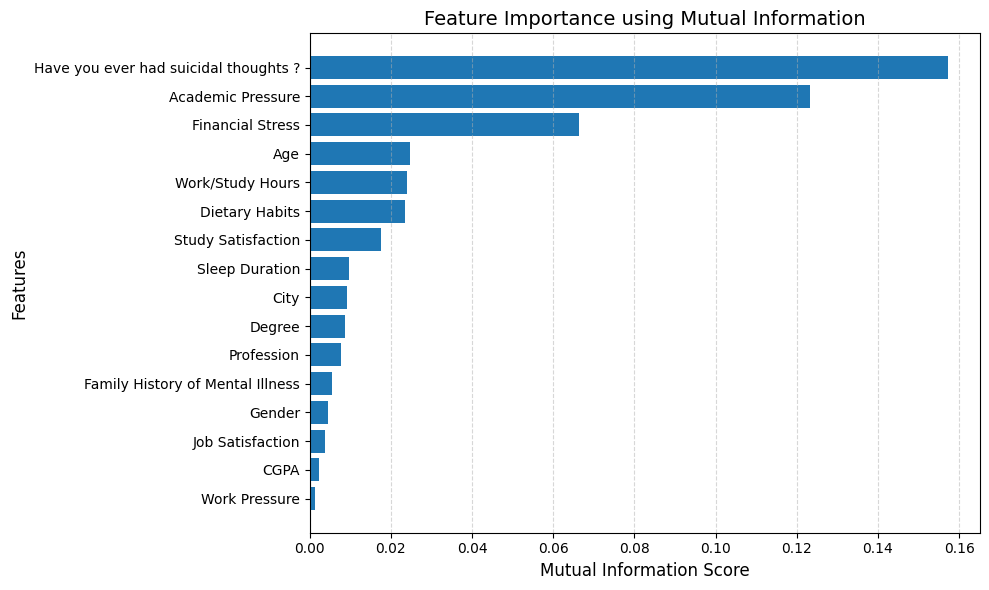

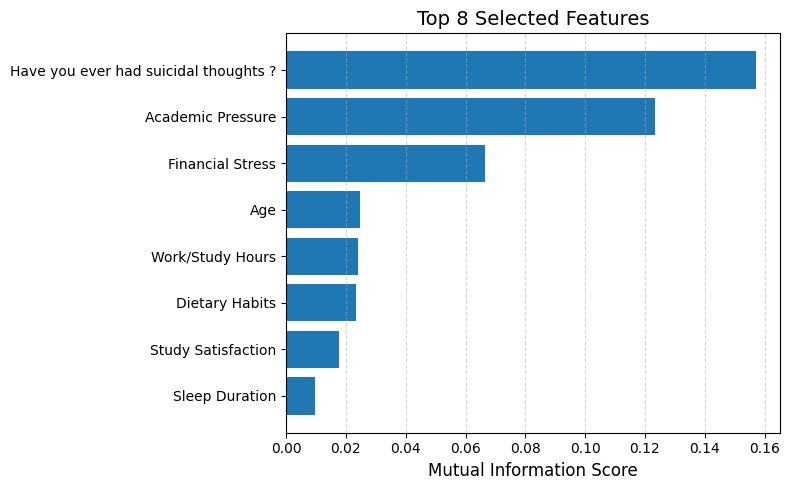


Feature Shape : (27000, 8)


In [9]:
# ==========================================================
# SEGMENT 4 : FEATURE SELECTION + VISUALIZATION
# ==========================================================

import matplotlib.pyplot as plt

n_qubits = 8

# Feature Selection
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=min(n_qubits, X_sampled.shape[1])
)

X_selected = selector.fit_transform(
    X_sampled,
    y_sampled
)

selected_features = np.array(feature_names)[selector.get_support()]
feature_scores = selector.scores_

print("\nSelected Features\n")

for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

# ==========================================================
# Feature Importance Plot
# ==========================================================

score_df = pd.DataFrame({
    "Feature": feature_names,
    "Score": feature_scores
})

score_df = score_df.sort_values(
    by="Score",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    score_df["Feature"],
    score_df["Score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mutual Information Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title("Feature Importance using Mutual Information", fontsize=14)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================================
# Selected Features Plot
# ==========================================================

selected_df = score_df.head(n_qubits)

plt.figure(figsize=(8,5))

plt.barh(
    selected_df["Feature"],
    selected_df["Score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mutual Information Score", fontsize=12)
plt.title(f"Top {n_qubits} Selected Features", fontsize=14)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================================
# Automatic Padding
# ==========================================================

if X_selected.shape[1] < n_qubits:

    padding = n_qubits - X_selected.shape[1]

    X_selected = np.pad(
        X_selected,
        ((0,0),(0,padding)),
        mode="constant",
        constant_values=0
    )

print("\nFeature Shape :", X_selected.shape)

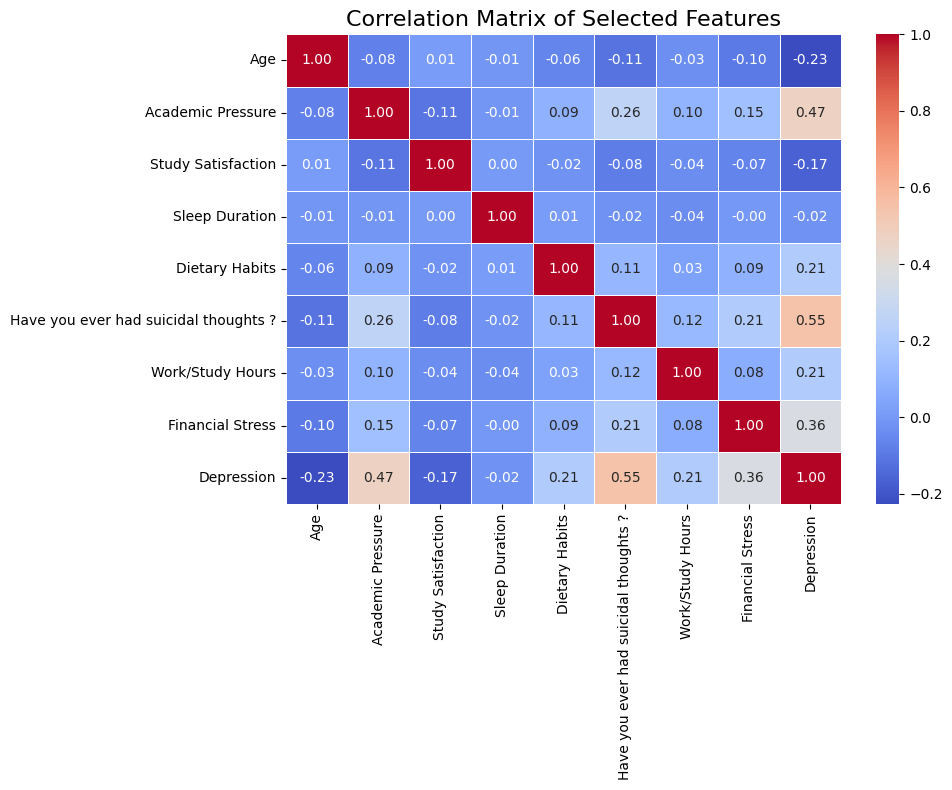

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = [
    "Age",
    "Academic Pressure",
    "Study Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts ?",
    "Work/Study Hours",
    "Financial Stress",
    "Depression"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[selected_features].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Selected Features", fontsize=16)
plt.tight_layout()

plt.savefig("Correlation_Selected_Features.png", dpi=600)

plt.show()

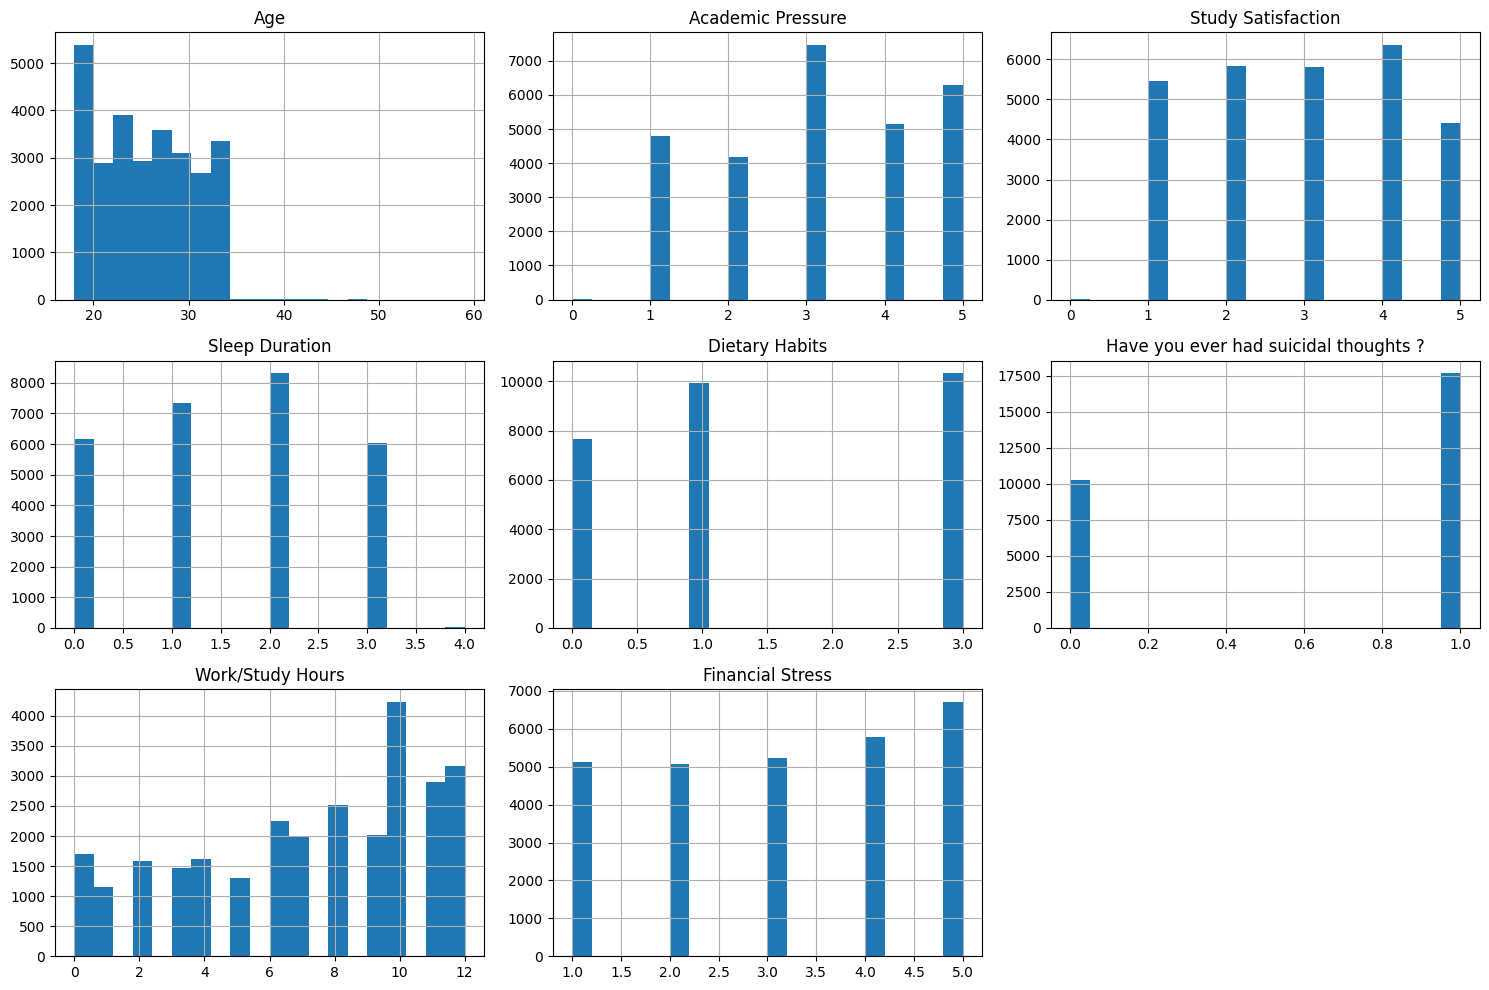

In [58]:
selected_features = [
    "Age",
    "Academic Pressure",
    "Study Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts ?",
    "Work/Study Hours",
    "Financial Stress"
]

df[selected_features].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.savefig("Histograms_Selected_Features.png", dpi=600)
plt.show()

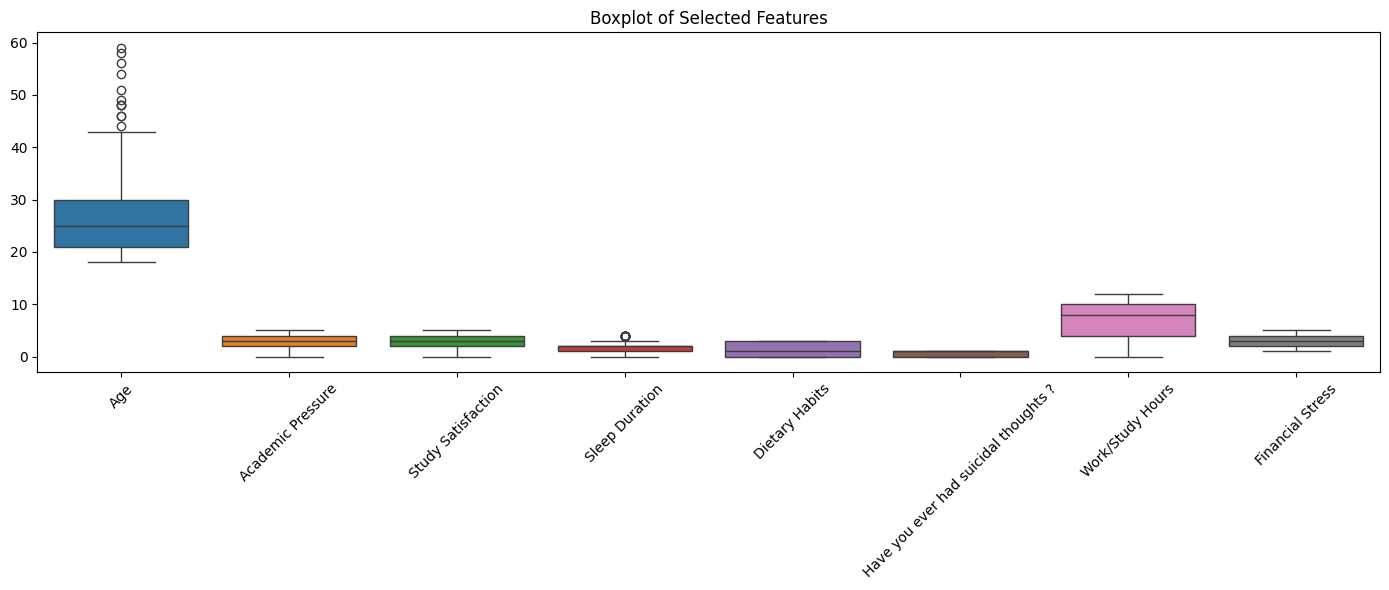

In [59]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df[selected_features])

plt.xticks(rotation=45)
plt.title("Boxplot of Selected Features")

plt.tight_layout()
plt.savefig("Boxplot_Selected_Features.png", dpi=600)

plt.show()

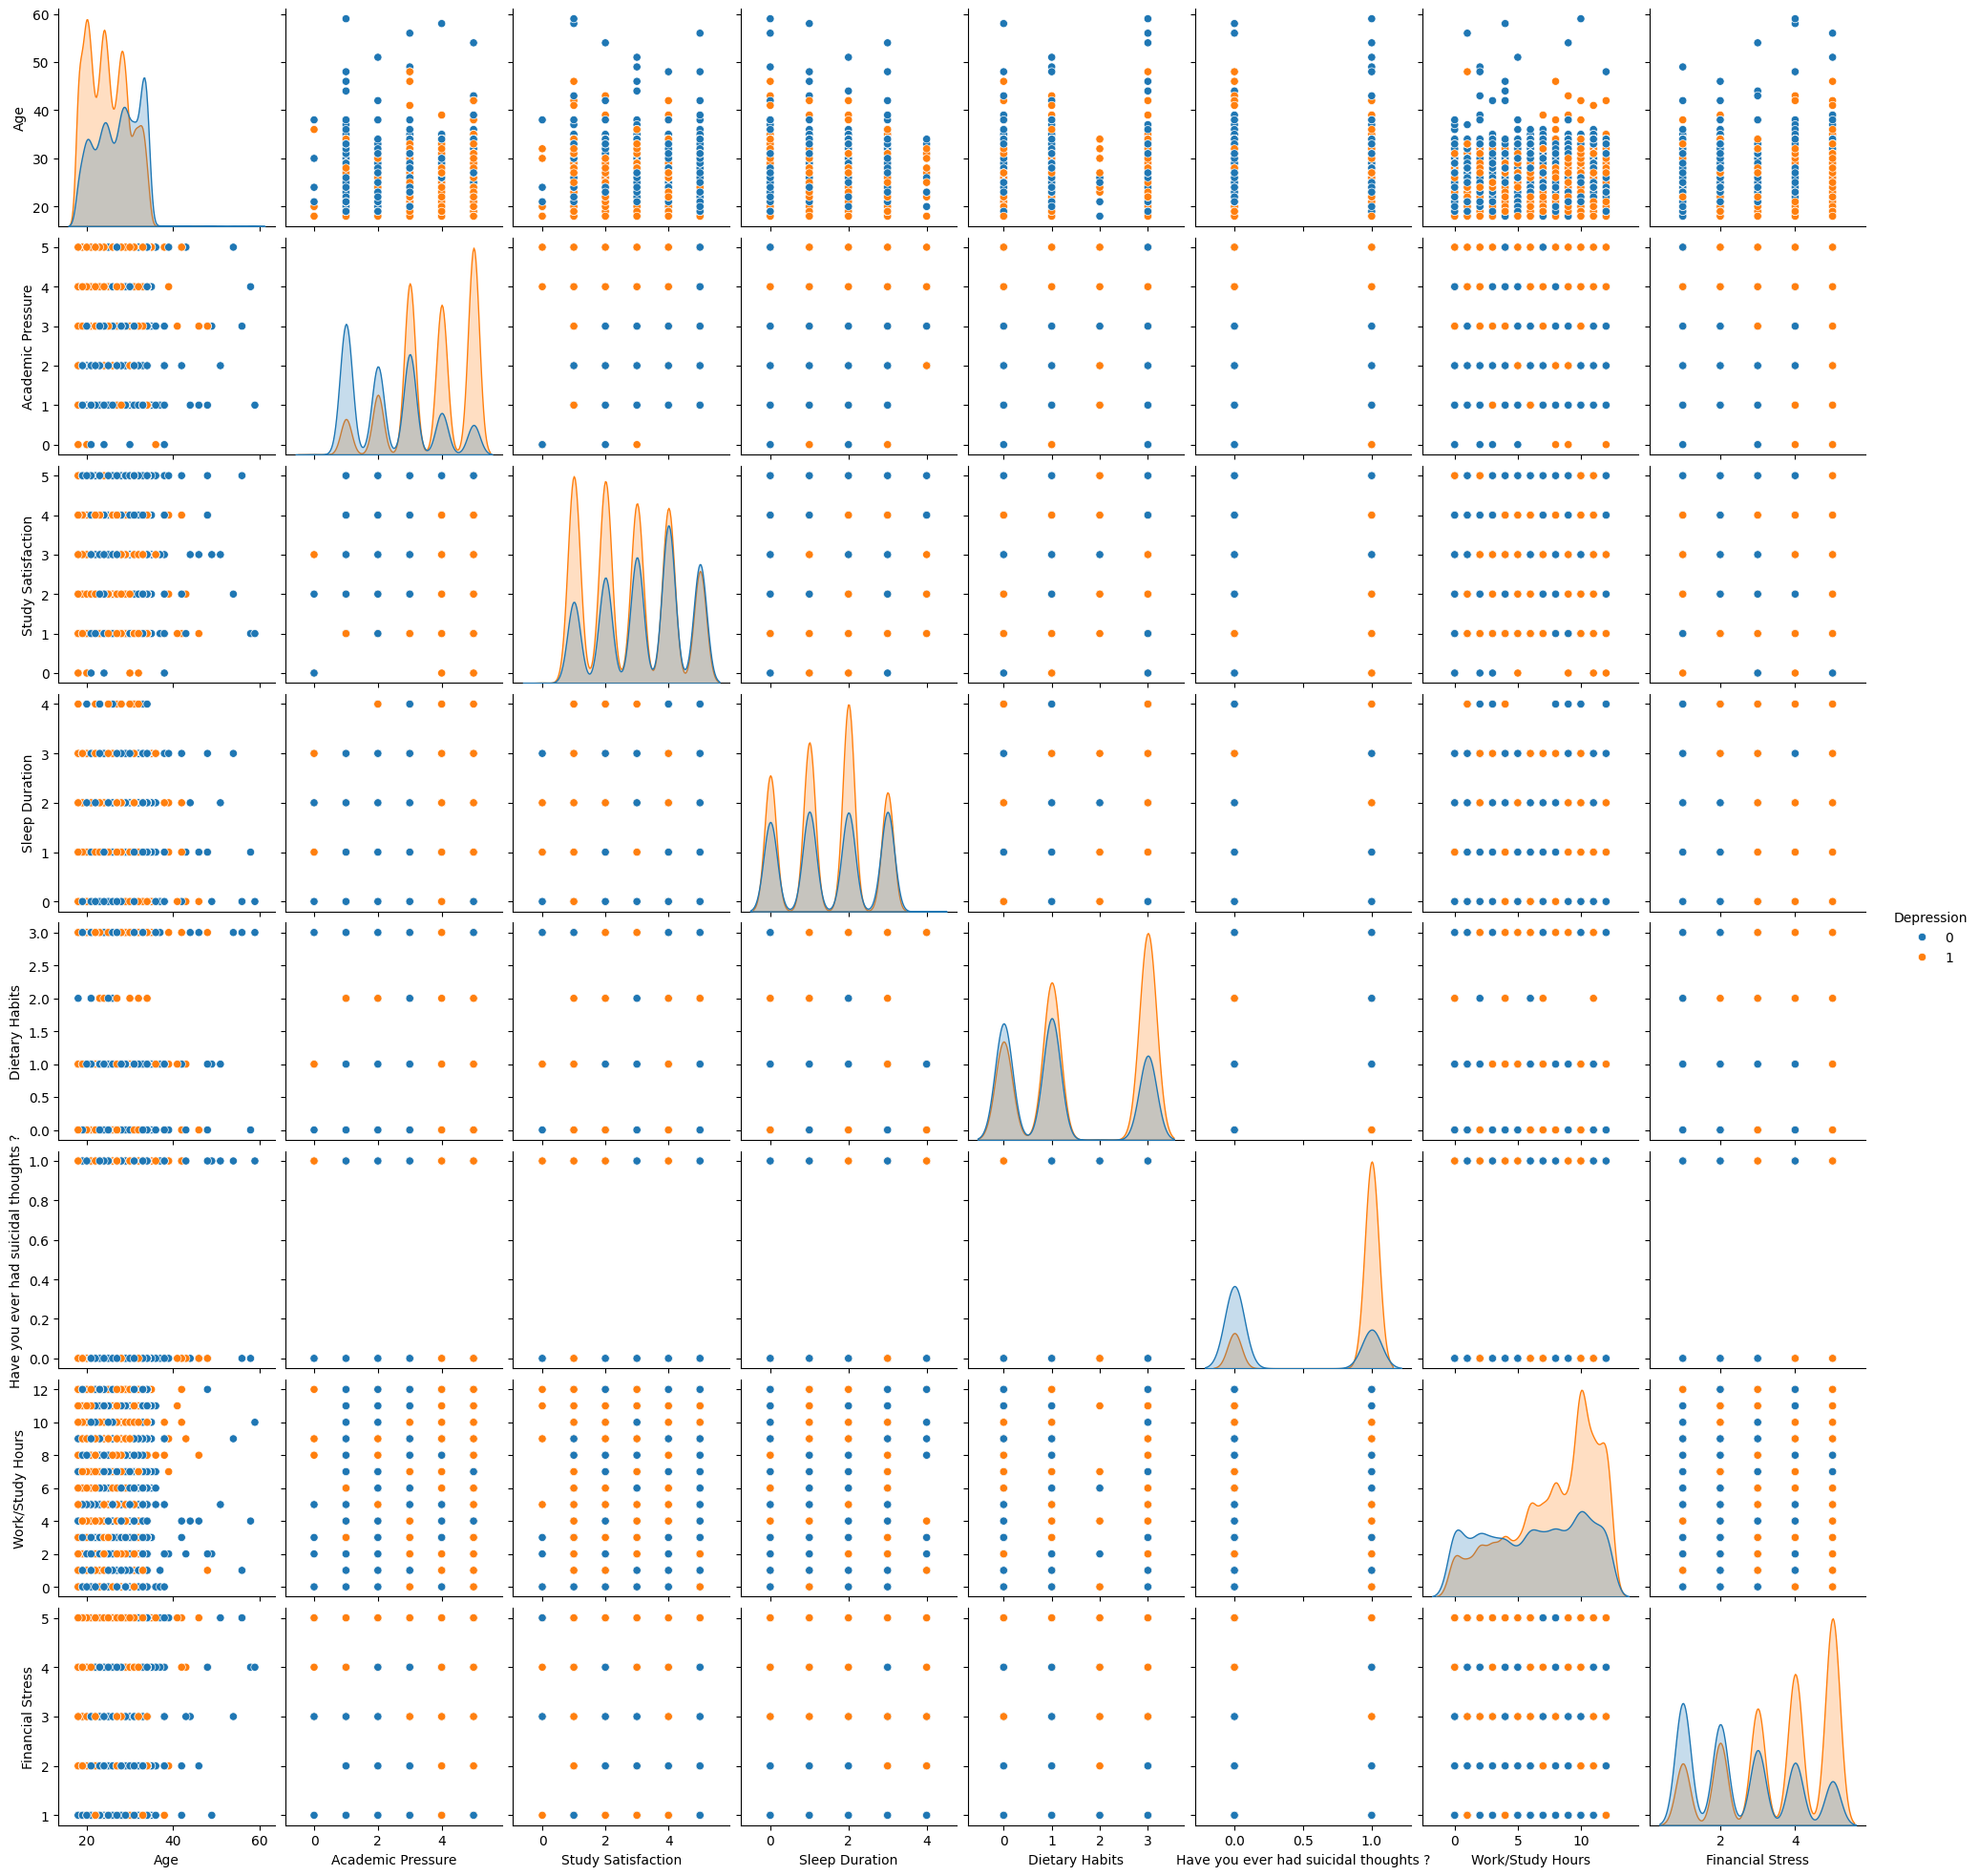

In [60]:
sns.pairplot(
    df[selected_features + ["Depression"]],
    hue="Depression"
)

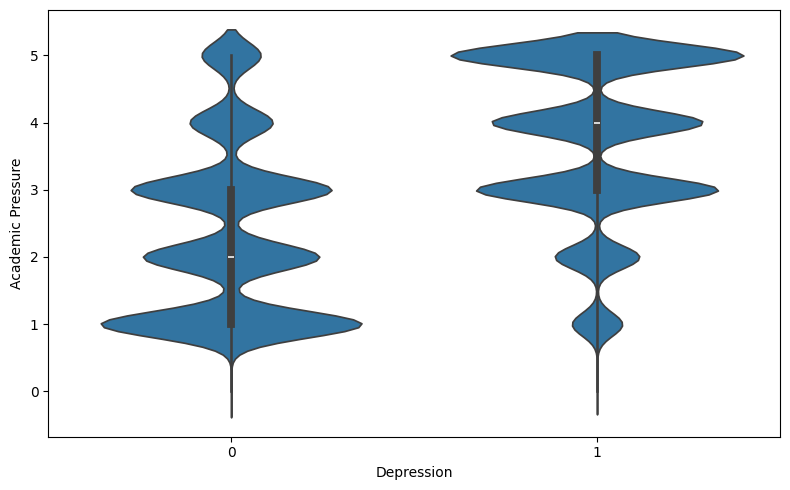

In [61]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x="Depression",
    y="Academic Pressure",
    data=df
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1385/2374823946.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


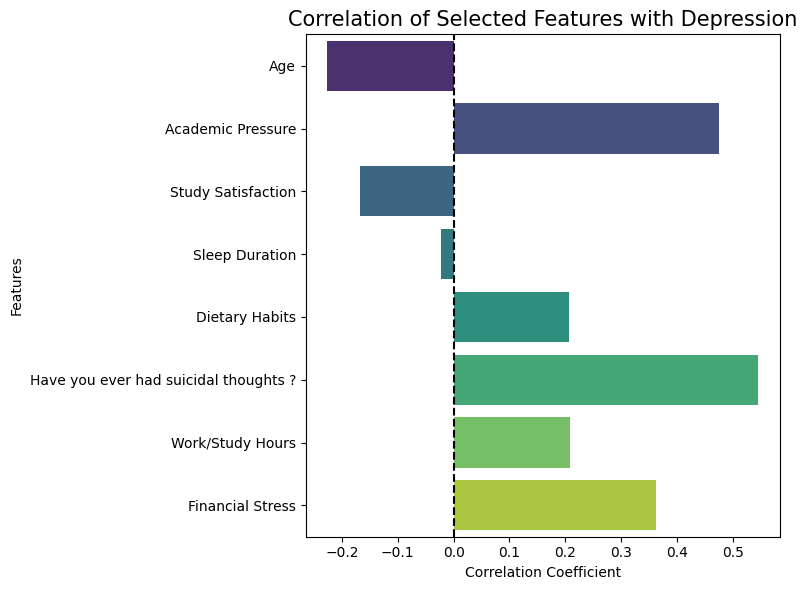

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = [
    "Age",
    "Academic Pressure",
    "Study Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts ?",
    "Work/Study Hours",
    "Financial Stress"
]

# Correlation with target
corr_target = df[selected_features + ["Depression"]].corr(numeric_only=True)["Depression"][:-1]

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    palette="viridis"
)

plt.title("Correlation of Selected Features with Depression", fontsize=15)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.axvline(0, color="black", linestyle="--")

plt.tight_layout()

plt.savefig(
    "Feature_Correlation_with_Target.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [12]:
dev = qml.device("lightning.gpu", wires=n_qubits)

@qml.qnode(dev)
def quantum_feature_map(x):

    qml.AngleEmbedding(
        features=x,
        wires=range(n_qubits),
        rotation="Y"
    )

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [13]:
dummy_x = np.random.random(n_qubits)

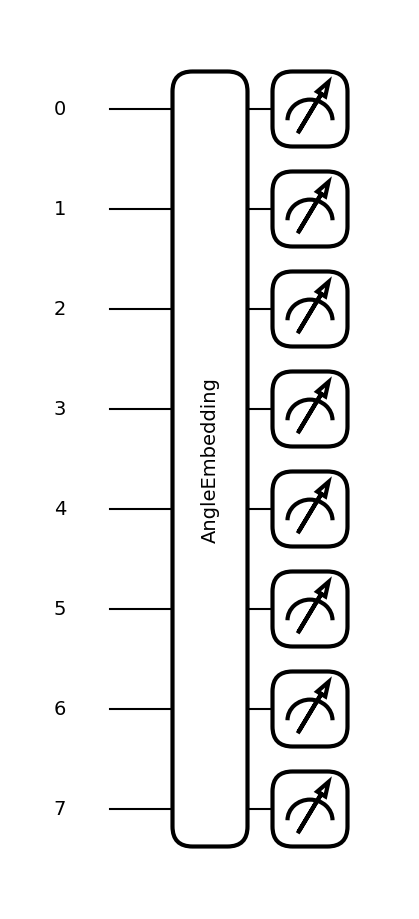

In [14]:
fig, ax = qml.draw_mpl(quantum_feature_map)(dummy_x)
plt.show()

In [15]:
import numpy as np
import time
from sklearn.model_selection import train_test_split

# ==========================================================
# PART-3 : Quantum Feature Extraction
# ==========================================================

def extract_quantum_features(X):

    q_features = []

    start_time = time.time()

    total = len(X)

    for i, sample in enumerate(X):

        q_features.append(
            quantum_feature_map(sample)
        )

        if (i + 1) % 20 == 0 or i == total - 1:

            elapsed = time.time() - start_time

            print(
                f"Processed {i+1}/{total} samples | "
                f"Elapsed: {elapsed:.2f} sec"
            )

    return np.array(q_features)

# ==========================================================
# DATA SPLIT
# ==========================================================

# Split the selected features into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_sampled,
    test_size=0.2, # 80% for training, 20% for testing
    random_state=42,
    stratify=y_sampled
)

print("\n" + "=" * 60)
print("Data Split Complete")
print("=" * 60)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


# ==========================================================
# TRAIN FEATURES
# ==========================================================

print("\n" + "=" * 60)
print("Extracting Quantum Training Features")
print("=" * 60)

start = time.time()

Q_train = extract_quantum_features(X_train)

print("\nTraining Quantum Feature Shape :", Q_train.shape)

print(f"Training Extraction Time : {time.time()-start:.2f} sec")


# ==========================================================
# TEST FEATURES
# ==========================================================

print("\n" + "=" * 60)
print("Extracting Quantum Testing Features")
print("=" * 60)

start = time.time()

Q_test = extract_quantum_features(X_test)

print("\nTesting Quantum Feature Shape :", Q_test.shape)

print(f"Testing Extraction Time : {time.time()-start:.2f} sec")


# ==========================================================
# CHECK
# ==========================================================

print("\nExample Quantum Feature Vector:\n")

print(Q_train[0])


Data Split Complete
X_train shape: (21600, 8)
X_test shape:  (5400, 8)
y_train shape: (21600,)
y_test shape:  (5400,)

Extracting Quantum Training Features
Processed 20/21600 samples | Elapsed: 0.34 sec
Processed 40/21600 samples | Elapsed: 0.38 sec
Processed 60/21600 samples | Elapsed: 0.42 sec
Processed 80/21600 samples | Elapsed: 0.46 sec
Processed 100/21600 samples | Elapsed: 0.50 sec
Processed 120/21600 samples | Elapsed: 0.55 sec
Processed 140/21600 samples | Elapsed: 0.60 sec
Processed 160/21600 samples | Elapsed: 0.64 sec
Processed 180/21600 samples | Elapsed: 0.68 sec
Processed 200/21600 samples | Elapsed: 0.73 sec
Processed 220/21600 samples | Elapsed: 0.78 sec
Processed 240/21600 samples | Elapsed: 0.82 sec
Processed 260/21600 samples | Elapsed: 0.86 sec
Processed 280/21600 samples | Elapsed: 0.93 sec
Processed 300/21600 samples | Elapsed: 1.00 sec
Processed 320/21600 samples | Elapsed: 1.06 sec
Processed 340/21600 samples | Elapsed: 1.12 sec
Processed 360/21600 samples | E

In [16]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [46]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=254,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=False
)

cat_model.fit(Q_train, y_train)

y_pred = cat_model.predict(Q_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8450
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      2238
           1       0.85      0.90      0.87      3162

    accuracy                           0.84      5400
   macro avg       0.84      0.83      0.84      5400
weighted avg       0.84      0.84      0.84      5400



In [47]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# CatBoost Model
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=254,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=False
)

# ============================
# 5-Fold Cross Validation
# ============================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    cat_model,
    Q_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold CV Accuracy:", cv_scores)
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

# ============================
# Train Final Model
# ============================
cat_model.fit(Q_train, y_train)

# Prediction
y_pred = cat_model.predict(Q_test)

# Test Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

5-Fold CV Accuracy: [0.85324074 0.84513889 0.84652778 0.84097222 0.83657407]
Mean Accuracy: 0.8445
Standard Deviation: 0.0056

Test Accuracy: 0.8450
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      2238
           1       0.85      0.90      0.87      3162

    accuracy                           0.84      5400
   macro avg       0.84      0.83      0.84      5400
weighted avg       0.84      0.84      0.84      5400



In [18]:
cat_model.fit(Q_train, y_train)

y_pred = cat_model.predict(Q_test)

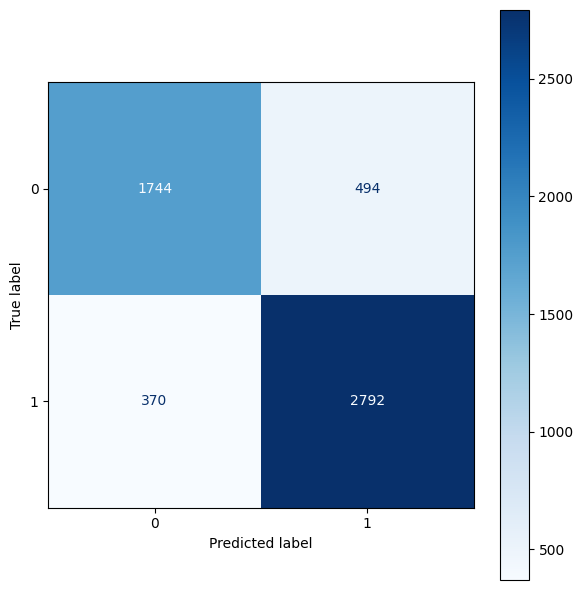

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d", ax=ax)

plt.tight_layout()
plt.show()

In [81]:
import pickle

filename = "Quantum_CatBoost_Model.sav"

pickle.dump(cat_model, open(filename, "wb"))

print("Quantum CatBoost Model Saved Successfully!")

Quantum CatBoost Model Saved Successfully!


In [76]:
y_pred = loaded_model.predict(Q_test)

print(y_pred)

[0 1 1 ... 0 0 1]


In [77]:
sample = Q_test[0].reshape(1, -1)

prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.85166015 0.14833985]]


In [78]:
prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)

print(f"Prediction: {prediction[0]}")

print(f"Not Depressed Probability : {probability[0][0]*100:.2f}%")
print(f"Depressed Probability     : {probability[0][1]*100:.2f}%")

if prediction[0] == 0:
    print("🟢 The student is NOT Depressed")
else:
    print("🔴 The student is Depressed")

Prediction: 0
Not Depressed Probability : 85.17%
Depressed Probability     : 14.83%
🟢 The student is NOT Depressed


In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.005,
    max_depth=1,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gb_model.fit(Q_train, y_train)

y_pred = gb_model.predict(Q_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.7783
              precision    recall  f1-score   support

           0       0.77      0.67      0.71      2238
           1       0.79      0.86      0.82      3162

    accuracy                           0.78      5400
   macro avg       0.78      0.76      0.77      5400
weighted avg       0.78      0.78      0.78      5400



5-Fold CV Accuracy: [0.84884259 0.82546296 0.83125    0.82777778 0.82291667]
Mean Accuracy: 0.8313
Std: 0.0092

Test Accuracy: 0.8369
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2238
           1       0.85      0.87      0.86      3162

    accuracy                           0.84      5400
   macro avg       0.83      0.83      0.83      5400
weighted avg       0.84      0.84      0.84      5400



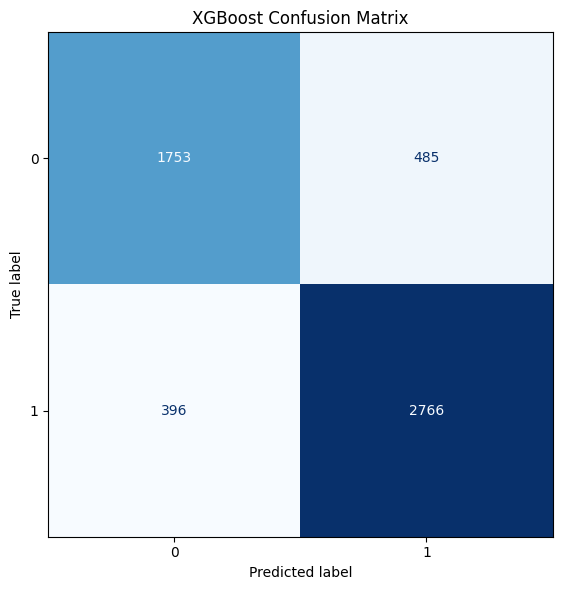

In [21]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=1100,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

# ============================
# 5-Fold Cross Validation
# ============================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    Q_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold CV Accuracy:", cv_scores)
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std: {np.std(cv_scores):.4f}")

# ============================
# Train Final Model
# ============================
xgb_model.fit(Q_train, y_train)

# Prediction
y_pred = xgb_model.predict(Q_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "XGBoost_Confusion_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

5-Fold CV Accuracy: [0.825      0.81689815 0.8224537  0.81180556 0.80277778]
Mean Accuracy: 0.8158
Std: 0.0079

Test Accuracy: 0.8189
              precision    recall  f1-score   support

           0       0.80      0.75      0.77      2238
           1       0.83      0.87      0.85      3162

    accuracy                           0.82      5400
   macro avg       0.82      0.81      0.81      5400
weighted avg       0.82      0.82      0.82      5400



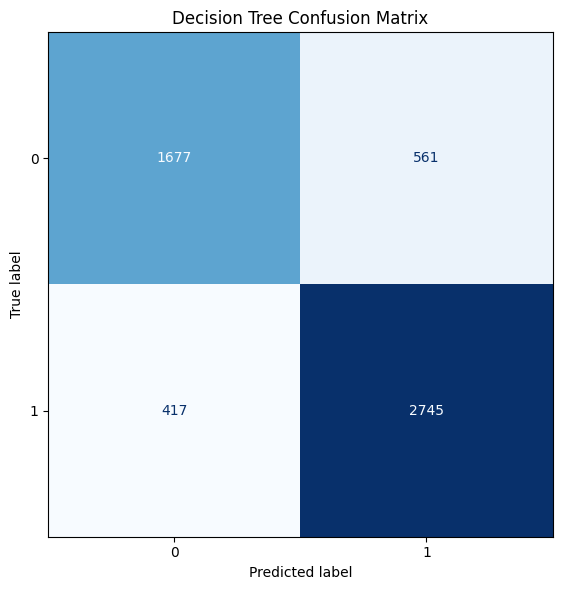

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Decision Tree Model
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# ============================
# 5-Fold Cross Validation
# ============================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    dt_model,
    Q_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold CV Accuracy:", cv_scores)
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std: {np.std(cv_scores):.4f}")

# ============================
# Train Final Model
# ============================
dt_model.fit(Q_train, y_train)

# Prediction
y_pred = dt_model.predict(Q_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "DecisionTree_Confusion_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

5-Fold CV Accuracy: [0.79282407 0.77962963 0.78611111 0.77777778 0.77569444]
Mean Accuracy: 0.7824
Std: 0.0063

Test Accuracy: 0.7783
              precision    recall  f1-score   support

           0       0.77      0.67      0.71      2238
           1       0.79      0.86      0.82      3162

    accuracy                           0.78      5400
   macro avg       0.78      0.76      0.77      5400
weighted avg       0.78      0.78      0.78      5400



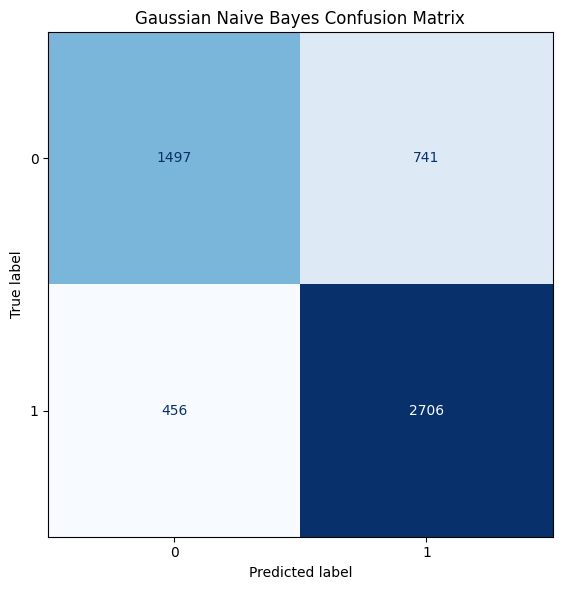

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Gaussian Naive Bayes Model
nb_model = GaussianNB()

# ============================
# 5-Fold Cross Validation
# ============================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    nb_model,
    Q_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold CV Accuracy:", cv_scores)
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std: {np.std(cv_scores):.4f}")

# ============================
# Train Final Model
# ============================
nb_model.fit(Q_train, y_train)

# Prediction
y_pred = nb_model.predict(Q_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "GaussianNB_Confusion_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

5-Fold CV Accuracy: [0.79328704 0.77986111 0.78587963 0.77685185 0.77569444]
Mean Accuracy: 0.7823
Std: 0.0065

Test Accuracy: 0.7789
              precision    recall  f1-score   support

           0       0.77      0.67      0.71      2238
           1       0.78      0.86      0.82      3162

    accuracy                           0.78      5400
   macro avg       0.78      0.76      0.77      5400
weighted avg       0.78      0.78      0.78      5400



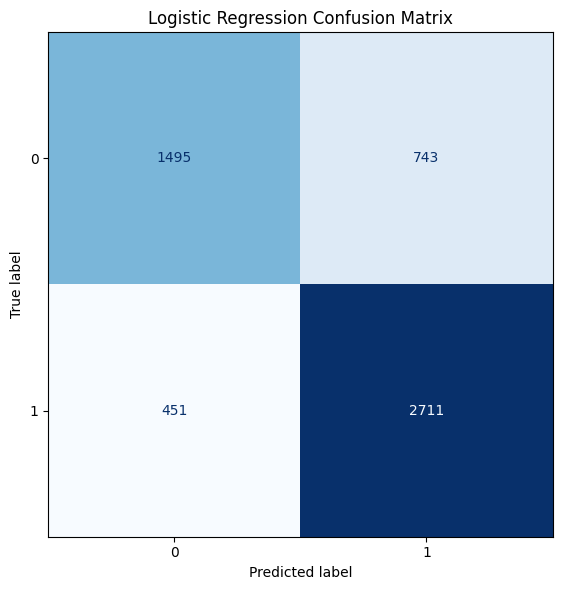

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression Model
lr_model = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

# ============================
# 5-Fold Cross Validation
# ============================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr_model,
    Q_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold CV Accuracy:", cv_scores)
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std: {np.std(cv_scores):.4f}")

# ============================
# Train Final Model
# ============================
lr_model.fit(Q_train, y_train)

# Prediction
y_pred = lr_model.predict(Q_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "LogisticRegression_Confusion_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Accuracy: 0.7783
              precision    recall  f1-score   support

           0       0.77      0.67      0.71      2238
           1       0.79      0.86      0.82      3162

    accuracy                           0.78      5400
   macro avg       0.78      0.76      0.77      5400
weighted avg       0.78      0.78      0.78      5400



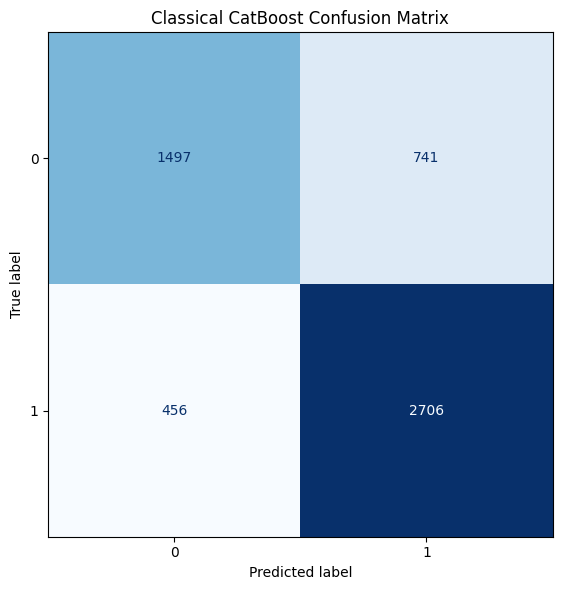

In [31]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classical CatBoost Model
cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.0001,
    depth=1,
    random_seed=42,
    verbose=False
)

# Train on Classical Features
cat_model.fit(X_train, y_train)

# Prediction
y_pred = cat_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

plt.title("Classical CatBoost Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "Classical_CatBoost_CM.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [69]:
import pickle

model_info = {
    "model": cat_model,
    "selected_features": selected_features
}

pickle.dump(model_info, open("Classical_CatBoost_Model.sav", "wb"))

In [70]:
import pickle

model_info = pickle.load(open("Classical_CatBoost_Model.sav", "rb"))

loaded_model = model_info["model"]
selected_features = model_info["selected_features"]

print(selected_features)

['Age', 'Academic Pressure', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress']


In [72]:
import numpy as np

# Example input (Label Encoded values)
input_data = (
    22,   # Age
    3,    # Academic Pressure
    2,    # Study Satisfaction
    1,    # Sleep Duration (Encoded)
    0,    # Dietary Habits (Encoded)
    1,    # Have you ever had suicidal thoughts? (Encoded)
    8,    # Work/Study Hours
    4     # Financial Stress
)

# Convert to NumPy array
input_data = np.asarray(input_data).reshape(1, -1)

# Prediction
prediction = loaded_model.predict(input_data)

print("Prediction:", prediction)

if prediction[0] == 0:
    print("The student is Not Depressed.")
else:
    print("The student is Depressed.")

Prediction: [0]
The student is Not Depressed.


In [40]:
pip install shap

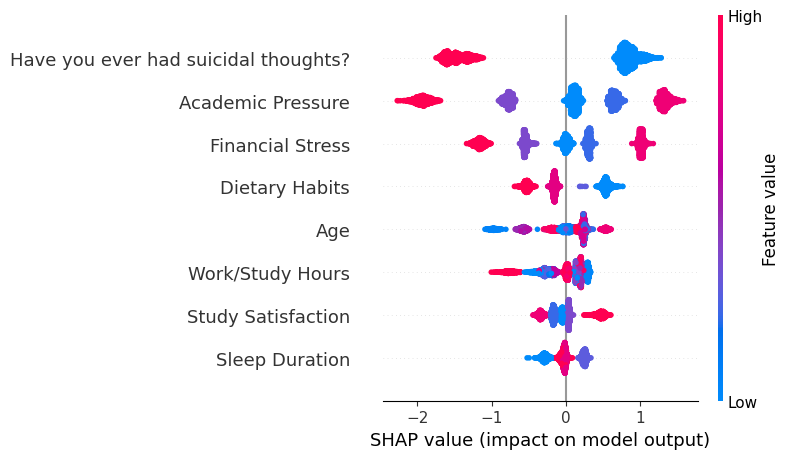

In [50]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Feature names
feature_names = [
    "Age",
    "Academic Pressure",
    "Study Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts?",
    "Work/Study Hours",
    "Financial Stress"
]
# Convert quantum features to DataFrame
Q_test_df = pd.DataFrame(Q_test, columns=feature_names)

# SHAP Explainer
explainer = shap.TreeExplainer(cat_model)

# SHAP values
shap_values = explainer.shap_values(Q_test_df)

# Summary Plot
plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    Q_test_df,
    show=False
)

plt.tight_layout()
plt.savefig(
    "SHAP_Summary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

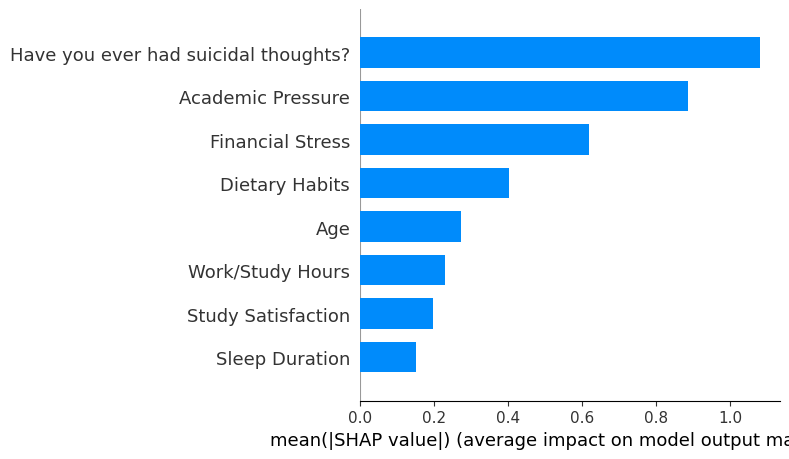

In [51]:
plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    Q_test_df,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "SHAP_Bar.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [52]:
! pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e7ab24a97ebb96482a4bad7fbd1679f7c3f996c420ad45501bd6384f0494e18b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


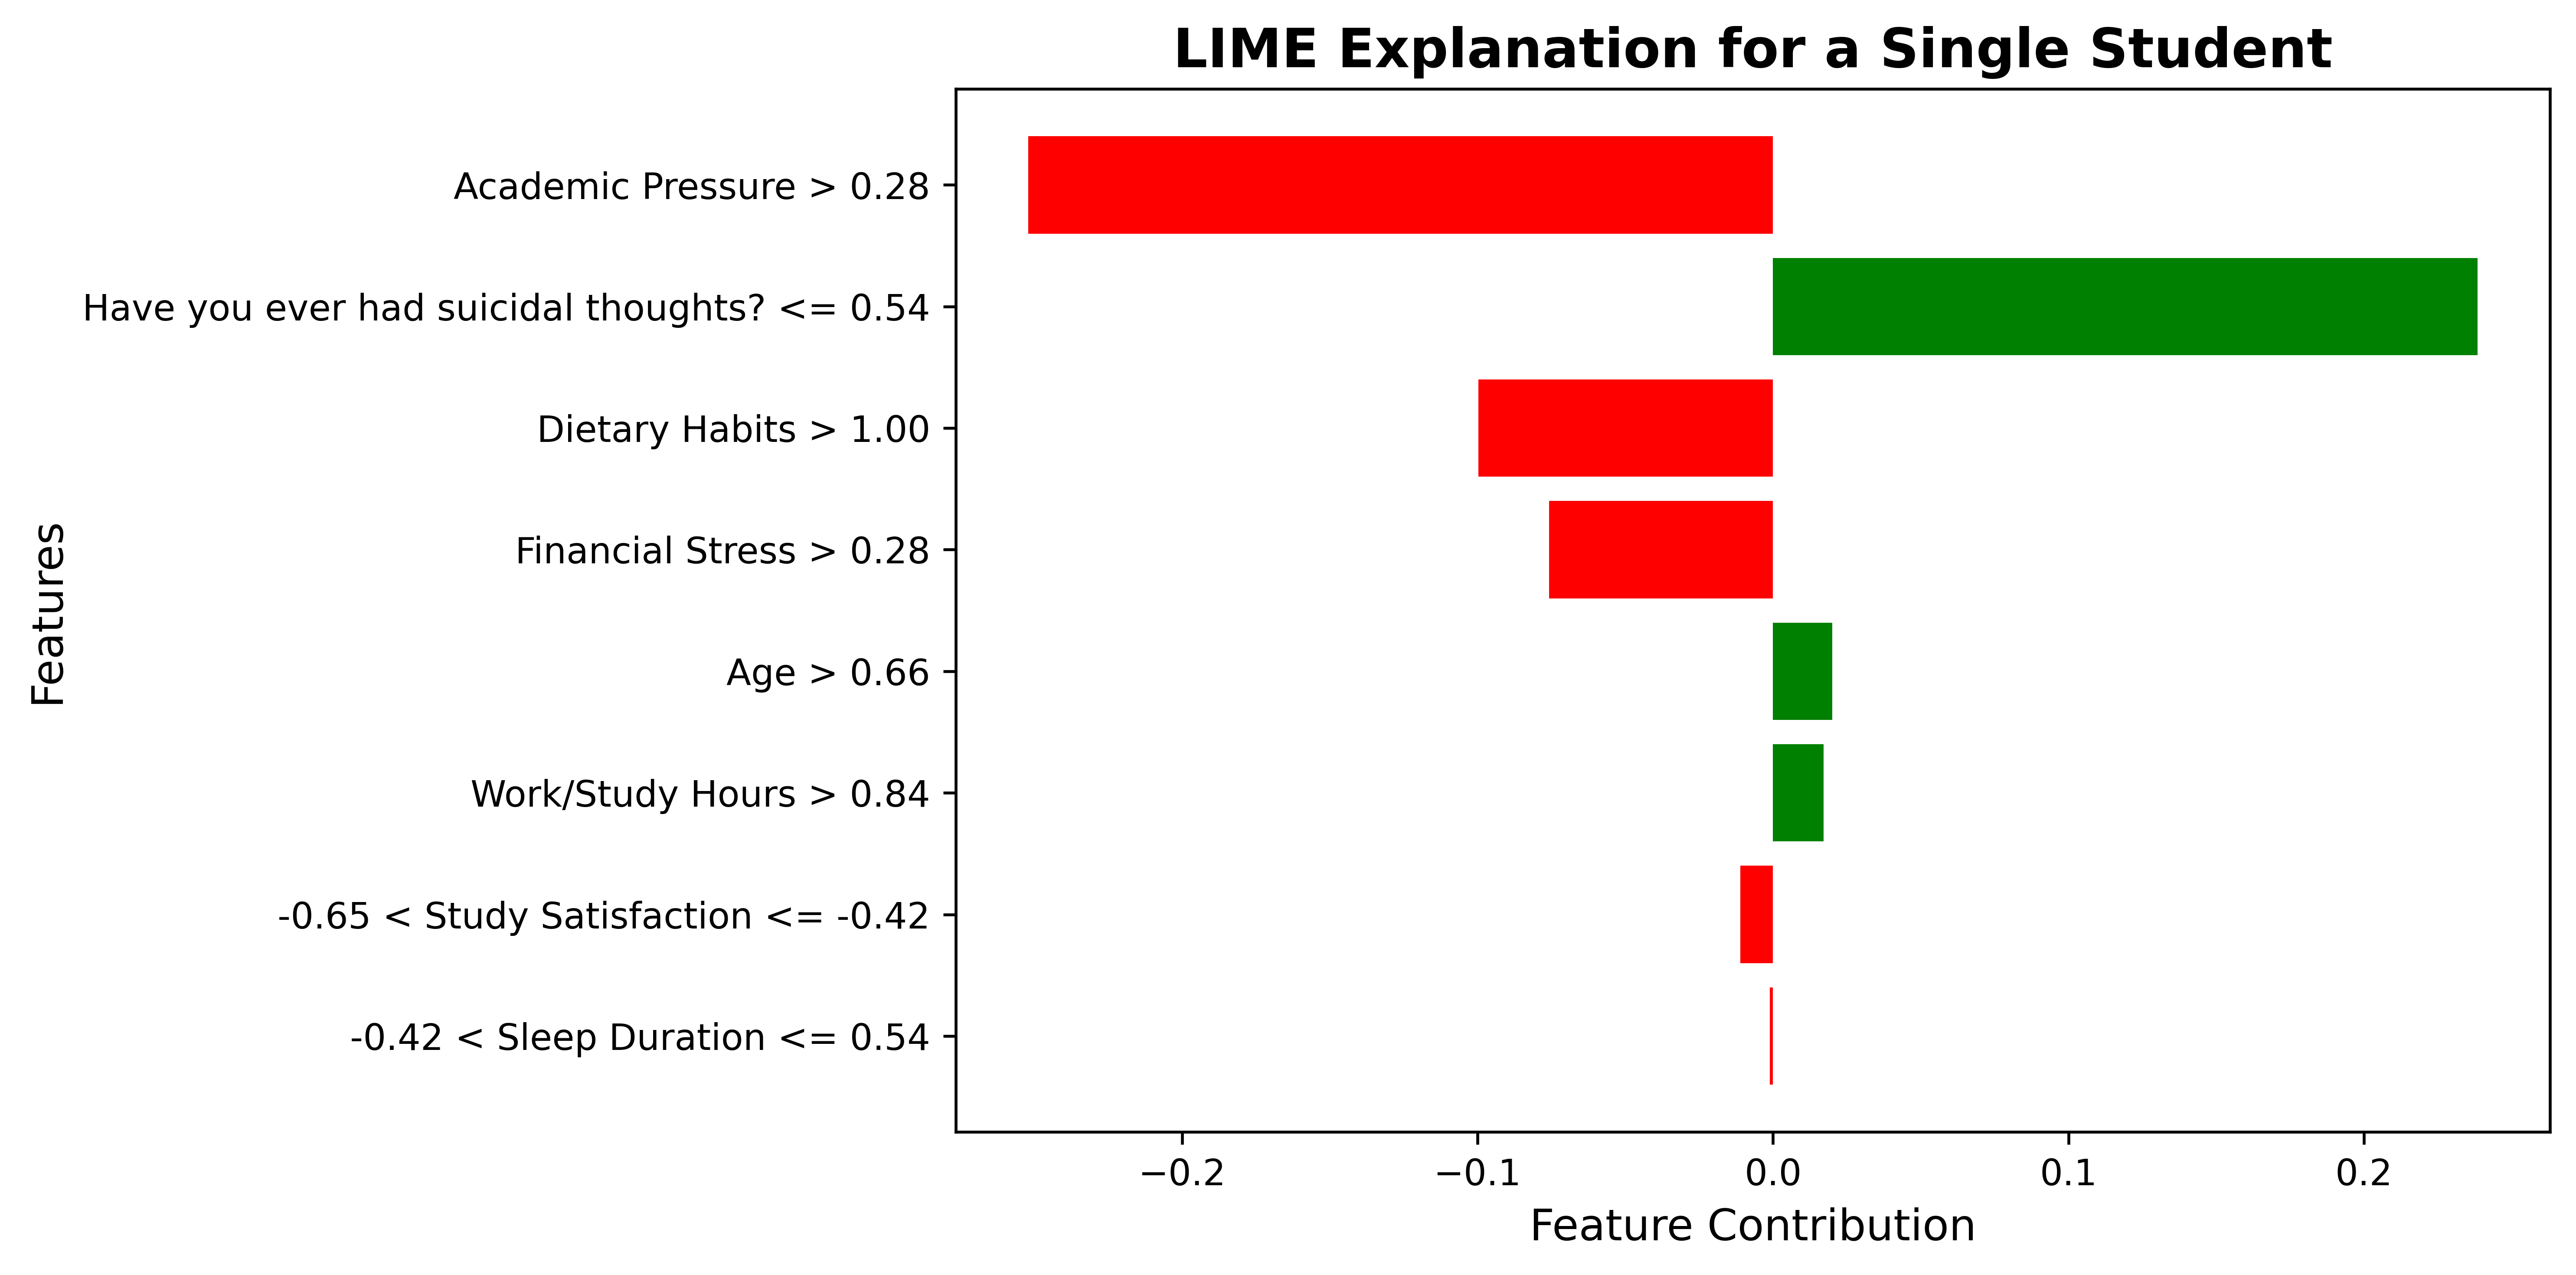

In [55]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np

# LIME Explainer
explainer = LimeTabularExplainer(
    training_data=np.array(Q_train),
    feature_names=feature_names,
    class_names=["Not Depressed", "Depressed"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Explain first sample
exp = explainer.explain_instance(
    Q_test[0],
    cat_model.predict_proba,
    num_features=8
)

# Create publication-quality figure
fig = exp.as_pyplot_figure()

fig.set_size_inches(10, 5)
fig.set_dpi(600)

plt.title(
    "LIME Explanation for a Single Student",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Feature Contribution", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()

plt.savefig(
    "LIME_Single_Student.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [54]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np

# Feature names
feature_names = [
    "Age",
    "Academic Pressure",
    "Study Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts?",
    "Work/Study Hours",
    "Financial Stress"
]

# Create LIME Explainer
explainer = LimeTabularExplainer(
    training_data=np.array(Q_train),
    feature_names=feature_names,
    class_names=["Not Depressed", "Depressed"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Explain one sample (first person)
sample_id = 0

exp = explainer.explain_instance(
    Q_test[sample_id],
    cat_model.predict_proba,
    num_features=8
)

# Show explanation in notebook
exp.show_in_notebook(show_table=True)

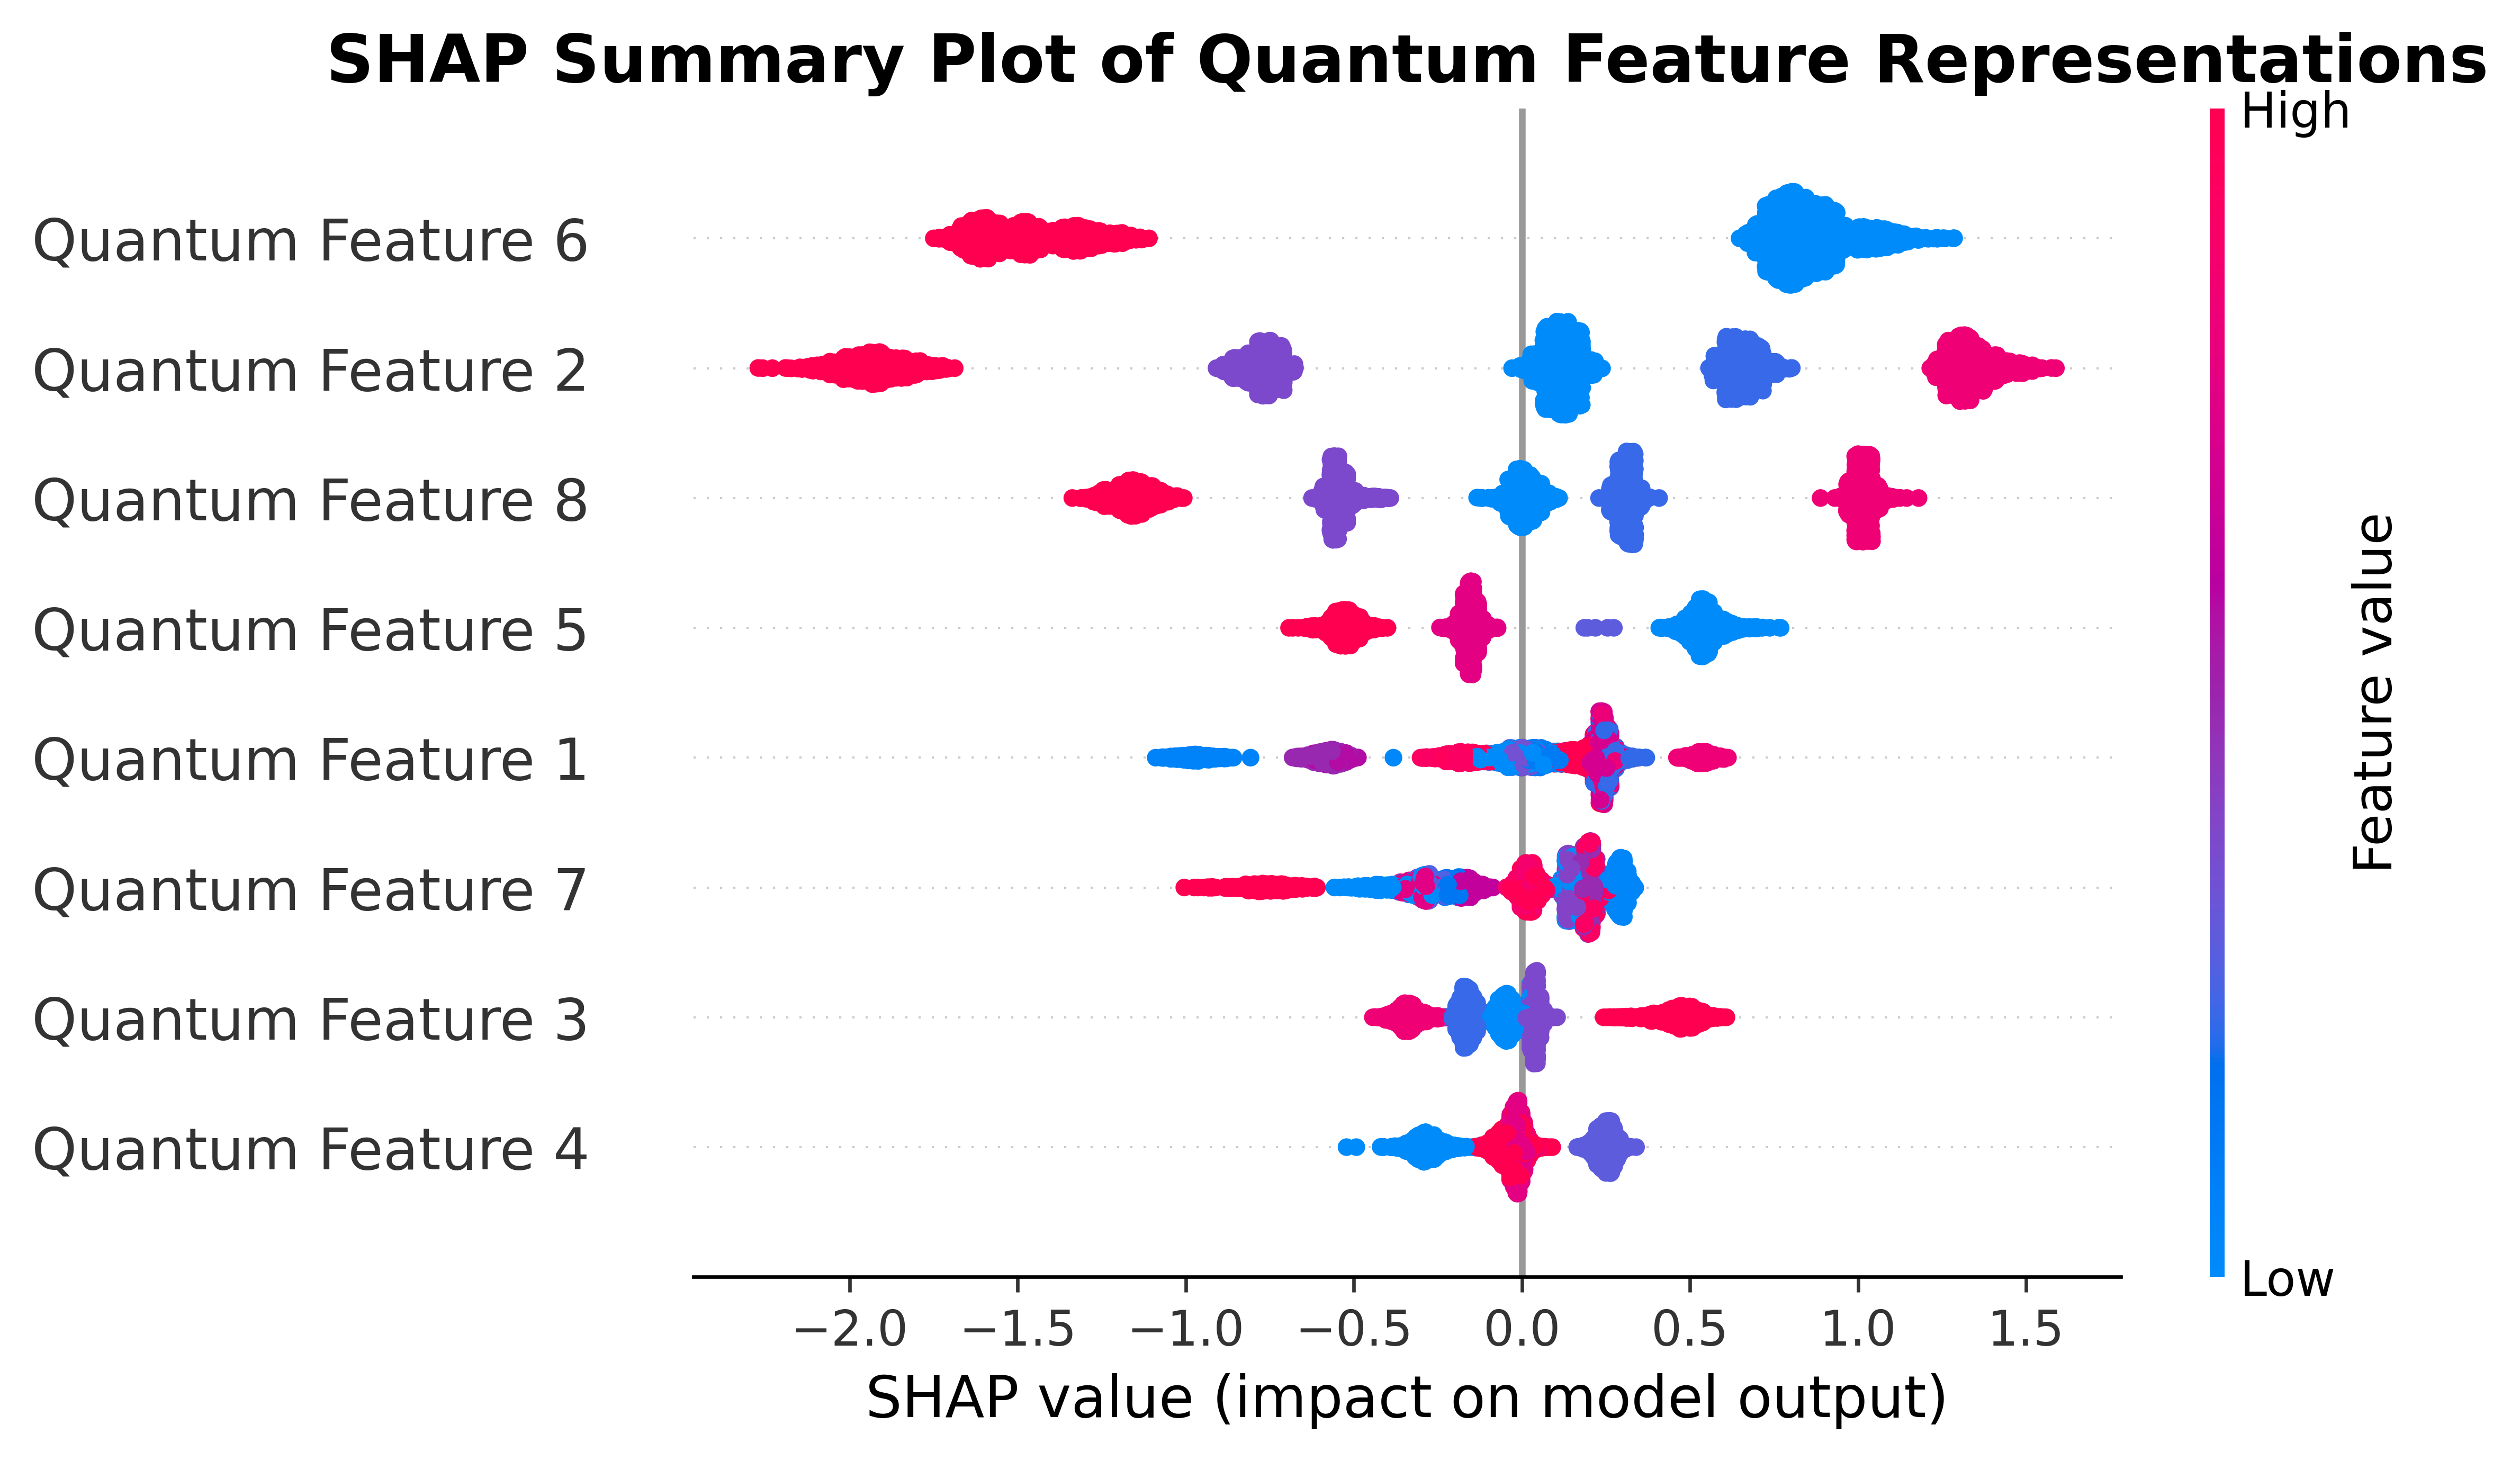

In [79]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Quantum Feature Names
feature_names = [
    "Quantum Feature 1",
    "Quantum Feature 2",
    "Quantum Feature 3",
    "Quantum Feature 4",
    "Quantum Feature 5",
    "Quantum Feature 6",
    "Quantum Feature 7",
    "Quantum Feature 8"
]

Q_test_df = pd.DataFrame(Q_test, columns=feature_names)

# SHAP Explainer
explainer = shap.TreeExplainer(cat_model)

# SHAP values
shap_values = explainer(Q_test_df)

# Summary Plot
plt.figure(figsize=(10,6), dpi=600)

shap.summary_plot(
    shap_values,
    Q_test_df,
    max_display=8,
    show=False
)

plt.title(
    "SHAP Summary Plot of Quantum Feature Representations",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "SHAP_Quantum_Summary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [80]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

feature_names = [
    "Quantum Feature 1",
    "Quantum Feature 2",
    "Quantum Feature 3",
    "Quantum Feature 4",
    "Quantum Feature 5",
    "Quantum Feature 6",
    "Quantum Feature 7",
    "Quantum Feature 8"
]

explainer = LimeTabularExplainer(
    training_data=np.array(Q_train),
    feature_names=feature_names,
    class_names=["Not Depressed", "Depressed"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

exp = explainer.explain_instance(
    Q_test[0],
    cat_model.predict_proba,
    num_features=8
)

exp.show_in_notebook(show_table=True)